## QQ plot for GWAS p-values

This notebook draws a quantile–quantile (QQ) plot to compare the **observed** GWAS p-value distribution
against the **expected** uniform distribution under the null hypothesis. Points deviating upward from the
diagonal indicate an excess of small p-values (e.g., true associations or test-statistic inflation).

In [ ]:
library(data.table)
library(ggplot2)
library(ggrepel)
library(LDlinkR)

# 1. Read GWAS results
gwas_data <- fread("../../results/reproducibility/gwas_resources/GCST90027164_buildGRCh38.tsv", header = TRUE, quote = "")


Loading required package: sysfonts

Loading required package: showtextdb



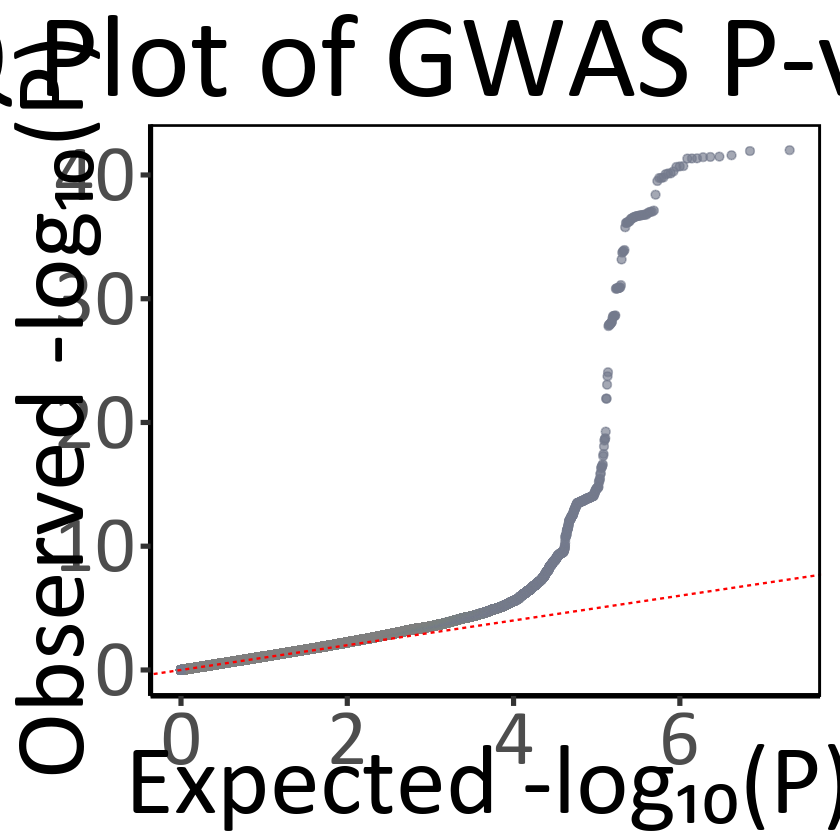

In [2]:
# -------- 0. Dependencies: ggplot2 + showtext (embed TrueType fonts) ----------
library(ggplot2)
library(showtext)      # If not installed: install.packages("showtext")

# -------- 1. Register and enable the Calibri font -------------------------------
# Default Windows path; on Linux/macOS replace "C:/Windows/Fonts/calibri.ttf"
# with the path to the TTF file you copied, e.g. "~/fonts/calibri.ttf"
font_add(family = "Calibri", regular = "/home/wangyubo/code/font/CALIBRI.TTF")
showtext_auto()        # Let ggplot2 render TrueType fonts via showtext

# -------- 2. Preprocess: ensure numeric p_value & drop NAs ----------------------
gwas_data$p_value <- as.numeric(gsub(",", ".", gwas_data$p_value))
gwas_data        <- gwas_data[!is.na(gwas_data$p_value), ]

# -------- 3. Compute expected & observed values (-log10 scale) ------------------------
gwas_data <- gwas_data[order(gwas_data$p_value), ]
gwas_data$expected <- -log10(ppoints(nrow(gwas_data)))
gwas_data$observed <- -log10(gwas_data$p_value)

# -------- 4. Plot ----------------------------------------------------
showtext_auto()          # Enable showtext
showtext_opts(dpi = 300) # Tell showtext to render/export at 300 DPI
p <- ggplot(gwas_data, aes(expected, observed)) +
  geom_point(size = 1.8, alpha = 0.65, colour = "#747a8c") +
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", colour = "red") +
  labs(title = "QQ Plot of GWAS P-values",
       x = "Expected -log₁₀(P)",
       y = "Observed -log₁₀(P)") +
  # theme_classic() removes grid lines; base_size controls the default text size
  theme_classic(base_family = "Calibri", base_size = 24) +
  # Add a border around the panel; fill = NA makes it transparent, colour = "black"
  theme(panel.border = element_rect(fill = NA, colour = "black", linewidth = 1),
        plot.title   = element_text(hjust = 0.5, face = "bold"))

# -------- 5. Export to PDF (embed Calibri glyphs) -------------------------
p